<a href="https://colab.research.google.com/github/enriquefroes/previsao-brasileirao-2026/blob/main/notebooks/04_jogos_decisivos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_previsao_brasileirao'
except ImportError:
    BASE = './analise_previsao_brasileirao'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

def exige(arquivo, notebook):
    if not os.path.exists(os.path.join(DADOS, arquivo)):
        raise FileNotFoundError(f'Rode primeiro o notebook {notebook}')

exige('forca_times.csv', '01_forca_dos_times')
p = pd.read_csv(os.path.join(DADOS, 'partidas_realizadas.csv'), parse_dates=['data'])
r = pd.read_csv(os.path.join(DADOS, 'jogos_restantes.csv'), parse_dates=['data'])
copas = pd.read_csv(os.path.join(DADOS, 'calendario_copas.csv'), parse_dates=['data'])
forca = pd.read_csv(os.path.join(DADOS, 'forca_times.csv'), index_col='time')
par = pd.read_csv(os.path.join(DADOS, 'parametros_modelo.csv'), index_col=0).iloc[:, 0]
times = sorted(forca.index)
idx = {t: i for i, t in enumerate(times)}
n = len(times)
ATK = np.log(forca.loc[times, 'ataque'].values)
DEF = np.log(forca.loc[times, 'defesa'].values)

def tabela_atual():
    pts, vit, gp, gc = (np.zeros(n) for _ in range(4))
    for _, g in p.iterrows():
        a, b, x, z = idx[g['mandante']], idx[g['visitante']], g['gols_mandante'], g['gols_visitante']
        gp[a] += x; gc[a] += z; gp[b] += z; gc[b] += x
        if x > z: pts[a] += 3; vit[a] += 1
        elif x < z: pts[b] += 3; vit[b] += 1
        else: pts[a] += 1; pts[b] += 1
    return pts, vit, gp, gc

def gols_esperados(desgaste=0.0, janela=3):
    """Gols esperados de mandante e visitante em cada jogo restante.
    desgaste: redução no ataque (e aumento nos gols sofridos) de quem tem jogo de copa a até `janela` dias."""
    H = np.array([idx[t] for t in r['mandante']]); A = np.array([idx[t] for t in r['visitante']])
    lh = np.exp(par['intercepto'] + par['mando'] + ATK[H] + DEF[A])
    la = np.exp(par['intercepto'] + ATK[A] + DEF[H])
    if desgaste:
        for k, j in r.iterrows():
            if pd.isna(j['data']):
                continue
            for lado, time in [('m', j['mandante']), ('v', j['visitante'])]:
                c = copas[copas['time'] == time]
                if ((c['data'] - j['data']).abs().dt.days <= janela).any():
                    if lado == 'm': lh[k] *= 1 - desgaste; la[k] *= 1 + desgaste
                    else: la[k] *= 1 - desgaste; lh[k] *= 1 + desgaste
    return H, A, lh, la

def simular(N=20000, desgaste=0.0, semente=42):
    rng = np.random.default_rng(semente)
    H, A, lh, la = gols_esperados(desgaste)
    gh = rng.poisson(lh, (N, len(r))); ga = rng.poisson(la, (N, len(r)))
    pts0, vit0, gp0, gc0 = tabela_atual()
    pts, vit, gp, gc = (np.tile(v, (N, 1)) for v in (pts0, vit0, gp0, gc0))
    for k in range(len(r)):
        h, a, x, z = H[k], A[k], gh[:, k], ga[:, k]
        pts[:, h] += 3 * (x > z) + (x == z); pts[:, a] += 3 * (z > x) + (x == z)
        vit[:, h] += x > z; vit[:, a] += z > x
        gp[:, h] += x; gc[:, h] += z; gp[:, a] += z; gc[:, a] += x

    chave = pts * 1e9 + vit * 1e6 + (gp - gc + 500) * 1e3 + gp + rng.random((N, n)) * 1e-3
    pos = (-chave).argsort(1).argsort(1) + 1
    return pts, pos, np.sign(gh - ga).astype(np.int8)


Mounted at /content/drive


In [2]:
exige('simulacoes.npz', '02_simulacao')
sim = np.load(os.path.join(DADOS, 'simulacoes.npz'))
pos, res = sim['pos'], sim['resultados']
eventos = {'titulo': pos == 1, 'top4': pos <= 4, 'top6': pos <= 6, 'z4': pos >= 17}

imp = {e: np.zeros(len(r)) for e in eventos}
for e, E in eventos.items():
    E = E.astype(float)
    probs = []
    for v in (1, 0, -1):
        m = (res == v).astype(float)
        probs.append((m.T @ E) / np.maximum(m.sum(0)[:, None], 1))
    probs = np.stack(probs)
    swing = probs.max(0) - probs.min(0)
    for k, (_, j) in enumerate(r.iterrows()):
        imp[e][k] = (swing[k, idx[j['mandante']]] + swing[k, idx[j['visitante']]]) * 100

jogos = r.copy()
jogos['jogo'] = jogos['mandante'] + ' x ' + jogos['visitante']
for e in eventos:
    jogos[f'imp_{e}'] = imp[e]
jogos['importancia'] = sum(imp[e] for e in eventos)
jogos = jogos.sort_values('importancia', ascending=False)
jogos.round(1).to_csv(os.path.join(TAB, '04_importancia_jogos.csv'), index=False)
jogos[['rodada', 'data', 'jogo', 'imp_titulo', 'imp_top6', 'imp_z4', 'importancia']].head(15).round(1)

,rodada,data,jogo,imp_titulo,imp_top6,imp_z4,importancia
58,34,2026-11-05,Cruzeiro x Bahia,0.0,54.9,0.0,101.8
91,38,2026-12-02,Bahia x Atlético-MG,0.0,63.2,0.0,96.9
46,33,2026-10-29,Atlético-MG x Cruzeiro,0.0,58.5,0.0,94.0
87,37,2026-11-29,Fluminense x Cruzeiro,0.1,32.1,0.0,91.8
7,29,2026-10-08,Athletico-PR x Atlético-MG,0.3,33.0,0.0,71.2
37,32,2026-10-24,Santos x Bahia,0.0,45.5,0.1,69.2
25,31,2026-10-18,Grêmio x Cruzeiro,0.0,21.6,26.2,67.9
12,30,2026-10-11,Atlético-MG x Santos,0.0,50.6,0.1,66.3
94,38,2026-12-02,Cruzeiro x Internacional,0.0,22.2,25.5,65.9
68,35,2026-11-18,Grêmio x Bahia,0.0,22.3,26.1,65.9


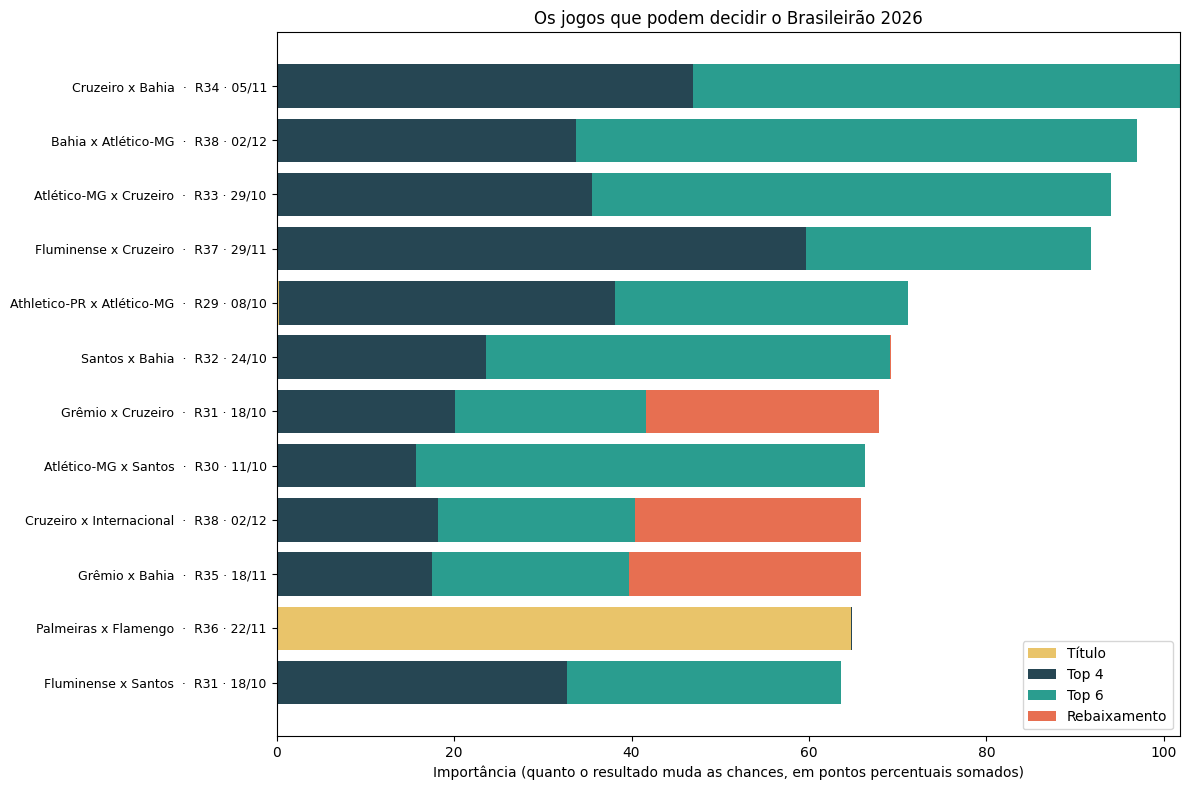

Salvo em /content/drive/MyDrive/analise_previsao_brasileirao/graficos/04a_jogos_mais_importantes.png


In [3]:
t = jogos.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(12, 8))
esq = np.zeros(len(t))
for col, cor, nome in [('imp_titulo', '#e9c46a', 'Título'), ('imp_top4', '#264653', 'Top 4'), ('imp_top6', '#2a9d8f', 'Top 6'), ('imp_z4', '#e76f51', 'Rebaixamento')]:
    ax.barh(range(len(t)), t[col], left=esq, color=cor, label=nome)
    esq += t[col].values
rot = [f"{j['jogo']}  ·  R{j['rodada']}" + (f" · {j['data']:%d/%m}" if pd.notna(j['data']) else '') for _, j in t.iterrows()]
ax.set_yticks(range(len(t))); ax.set_yticklabels(rot, fontsize=9)
ax.set_xlabel('Importância (quanto o resultado muda as chances, em pontos percentuais somados)')
ax.set_title('Os jogos que podem decidir o Brasileirão 2026', fontsize=12)
ax.legend(loc='lower right')
salvar('04a_jogos_mais_importantes.png')

In [4]:
for e, nome in [('imp_titulo', 'TÍTULO'), ('imp_top6', 'TOP 6'), ('imp_z4', 'REBAIXAMENTO')]:
    print(f'\n{nome}')
    print(jogos.sort_values(e, ascending=False).head(5)[['rodada', 'jogo', e]].round(1).to_string(index=False))

por_time = []
for t in times:
    j = jogos[(jogos['mandante'] == t) | (jogos['visitante'] == t)].iloc[0]
    por_time.append({'time': t, 'jogo_mais_importante': j['jogo'], 'rodada': j['rodada'], 'importancia': round(j['importancia'], 1)})
pd.DataFrame(por_time).sort_values('importancia', ascending=False)


TÍTULO
 rodada                   jogo  imp_titulo
     36   Palmeiras x Flamengo        64.7
     30  Flamengo x Fluminense        19.7
     34      Flamengo x Grêmio        19.0
     33       Vasco x Flamengo        18.1
     38 Flamengo x Chapecoense        18.1

TOP 6
 rodada                   jogo  imp_top6
     38    Bahia x Atlético-MG      63.2
     33 Atlético-MG x Cruzeiro      58.5
     34       Cruzeiro x Bahia      54.9
     30   Atlético-MG x Santos      50.6
     32         Santos x Bahia      45.5

REBAIXAMENTO
 rodada                     jogo  imp_z4
     30   Grêmio x Internacional    62.1
     31 Mirassol x Internacional    58.3
     38        Grêmio x Mirassol    55.3
     37     Corinthians x Grêmio    52.5
     36  Internacional x Vitória    51.5


,time,jogo_mais_importante,rodada,importancia
2,Bahia,Cruzeiro x Bahia,34,101.8
8,Cruzeiro,Cruzeiro x Bahia,34,101.8
1,Atlético-MG,Bahia x Atlético-MG,38,96.9
10,Fluminense,Fluminense x Cruzeiro,37,91.8
0,Athletico-PR,Athletico-PR x Atlético-MG,29,71.2
16,Santos,Santos x Bahia,32,69.2
11,Grêmio,Grêmio x Cruzeiro,31,67.9
12,Internacional,Cruzeiro x Internacional,38,65.9
9,Flamengo,Palmeiras x Flamengo,36,64.8
14,Palmeiras,Palmeiras x Flamengo,36,64.8


In [5]:

TIME = 'Atlético-MG'
j = jogos[(jogos['mandante'] == TIME) | (jogos['visitante'] == TIME)].sort_values('rodada')
k = [r.index.get_loc(i) for i in j.index]
E = (pos[:, idx[TIME]] <= 6).astype(float)
linhas = []
for i, (_, x) in zip(k, j.iterrows()):
    casa = x['mandante'] == TIME
    v, d = (1, -1) if casa else (-1, 1)
    linhas.append({'rodada': x['rodada'], 'jogo': x['jogo'],
                   'top6_se_vencer': E[res[:, i] == v].mean() * 100, 'top6_se_empatar': E[res[:, i] == 0].mean() * 100,
                   'top6_se_perder': E[res[:, i] == d].mean() * 100})
z = pd.DataFrame(linhas)
print(f'{TIME}: chance de top 6 hoje = {E.mean()*100:.1f}%')
z.round(1)

Atlético-MG: chance de top 6 hoje = 44.4%


,rodada,jogo,top6_se_vencer,top6_se_empatar,top6_se_perder
0,29,Athletico-PR x Atlético-MG,62.1,43.4,35.5
1,30,Atlético-MG x Santos,57.3,36.7,28.3
2,31,Atlético-MG x Coritiba,52.6,36.3,28.6
3,32,Flamengo x Atlético-MG,64.0,46.6,39.2
4,33,Atlético-MG x Cruzeiro,58.4,38.8,27.2
5,34,Botafogo x Atlético-MG,58.4,41.0,33.0
6,35,Mirassol x Atlético-MG,57.1,39.8,33.5
7,36,Atlético-MG x Corinthians,54.6,37.4,30.3
8,37,Atlético-MG x Vasco,53.7,36.1,30.6
9,38,Bahia x Atlético-MG,64.4,42.6,32.0


In [6]:
TIME = 'Cruzeiro'
j = jogos[(jogos['mandante'] == TIME) | (jogos['visitante'] == TIME)].sort_values('rodada')
k = [r.index.get_loc(i) for i in j.index]
E = (pos[:, idx[TIME]] <= 6).astype(float)
linhas = []
for i, (_, x) in zip(k, j.iterrows()):
    casa = x['mandante'] == TIME
    v, d = (1, -1) if casa else (-1, 1)
    linhas.append({'rodada': x['rodada'], 'jogo': x['jogo'],
                   'top6_se_vencer': E[res[:, i] == v].mean() * 100, 'top6_se_empatar': E[res[:, i] == 0].mean() * 100,
                   'top6_se_perder': E[res[:, i] == d].mean() * 100})
z = pd.DataFrame(linhas)
print(f'{TIME}: chance de top 6 hoje = {E.mean()*100:.1f}%')
z.round(1)

Cruzeiro: chance de top 6 hoje = 71.2%


,rodada,jogo,top6_se_vencer,top6_se_empatar,top6_se_perder
0,29,Cruzeiro x São Paulo,80.2,65.9,58.9
1,30,Bragantino x Cruzeiro,84.2,69.5,62.0
2,31,Grêmio x Cruzeiro,81.9,67.3,60.3
3,32,Cruzeiro x Remo,77.8,61.6,56.2
4,33,Atlético-MG x Cruzeiro,87.3,72.9,60.1
5,34,Cruzeiro x Bahia,82.7,67.3,55.6
6,35,Cruzeiro x Palmeiras,84.6,69.9,64.0
7,36,Chapecoense x Cruzeiro,79.8,64.3,59.1
8,37,Fluminense x Cruzeiro,85.1,70.4,63.5
9,38,Cruzeiro x Internacional,79.6,62.5,57.4
